# Modelos predictores de Implied Volatility







El **objetivo** de este notebook es aplicar diversos modelos y técnicas de IA y RRNN para encontrar el mejor modelo capaz de hacer una predicción con el mínimo error de la Volatilidad Implícita de trades de opciones del IBEX 35.

In [1]:
from src.volatility_models.data_utils import TrainingDataHandler

from src.volatility_models.training_utils import Trainer
from src.python_models.volatility_models.volatility_model_family import (
    LinearRegressionFamily,
    RandomForestFamily,
    XGBoostFamily,
    SequentialNNFamily, 
)
from src.python_models.volatility_models.volatility_model_family import TrainingPhase

## Selección de variables, Splits y  Feature Engineering

In [2]:
# Columnas escogidas para features + target + auditoría
volatility_df = TrainingDataHandler.load_volatility_db()
print("Rows loaded:", len(volatility_df))
display(volatility_df.head())

Rows loaded: 314877


,ExecDatetime,OptionContractCode,OptionType,Quantity,StrikePrice,TradeType,UnderlyingLagMinutes,UnderlyingPrice,TimeToExpiration,Rate,ImpliedVolatility
0,2017-01-02 09:13:43,CIBX 9600F17,C,3,9600.0,M,0.433333,9305.0,18.344641,-0.494698,0.175114
1,2017-01-02 09:23:09,PIBX 8200F17,P,5000,8200.0,H,0.1,9314.0,18.338091,-0.494875,0.265431
2,2017-01-02 09:24:08,CIBX 9300F17,C,1,9300.0,M,0.816667,9314.0,18.337408,-0.494893,0.189698
3,2017-01-02 09:29:21,PIBX 8500F17,P,5000,8500.0,H,0.333333,9322.0,18.333784,-0.494991,0.243136
4,2017-01-02 09:32:52,CIBX 9400F17,C,1,9400.0,M,0.0,9331.0,18.331343,-0.495057,0.185167


Adicionalmente, hay que crear un catálogo de las variables categóricas porque hay que aplicarle one-hot encoding.

In [3]:
train_df, val_df, test_df = TrainingDataHandler.load_splitted_data()

2026-04-13 23:27:24,387 | INFO | src.volatility_models.data_utils | Contract-code leakage control applied | overlapping contracts: 156 | removed rows -> train: 462, val: 1253, test: 290
2026-04-13 23:27:24,437 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-13 23:27:24,438 | INFO | src.volatility_models.data_utils | SPLIT TEMPORAL INICIAL (sobre todo el dataset): Train / Valid / Test
2026-04-13 23:27:24,438 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-13 23:27:24,439 | INFO | src.volatility_models.data_utils | Total filas: 312,872 | Total fechas: 1,402
2026-04-13 23:27:24,439 | INFO | src.volatility_models.data_utils | Train | rows:  250,469 ( 80.05%) | dates: 1,012 ( 72.18%) | range: 2017-01-02 -> 2020-12-17
2026-04-13 23:27:24,439 | INFO | src.volatility_models.data_utils | Valid | ro

In [4]:
# Seleccionamos columnas finales
train_df, val_df, test_df = TrainingDataHandler.load_full_features_splitted_data()
print(f"Total rows adding up all dataframes: {len(train_df)+len(val_df)+len(test_df)}")

2026-04-13 23:27:26,706 | INFO | src.volatility_models.data_utils | Contract-code leakage control applied | overlapping contracts: 156 | removed rows -> train: 462, val: 1253, test: 290
2026-04-13 23:27:26,742 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-13 23:27:26,742 | INFO | src.volatility_models.data_utils | SPLIT TEMPORAL INICIAL (sobre todo el dataset): Train / Valid / Test
2026-04-13 23:27:26,742 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-13 23:27:26,742 | INFO | src.volatility_models.data_utils | Total filas: 312,872 | Total fechas: 1,402
2026-04-13 23:27:26,742 | INFO | src.volatility_models.data_utils | Train | rows:  250,469 ( 80.05%) | dates: 1,012 ( 72.18%) | range: 2017-01-02 -> 2020-12-17
2026-04-13 23:27:26,758 | INFO | src.volatility_models.data_utils | Valid | ro

Total rows adding up all dataframes: 312872


In [5]:
folds = TrainingDataHandler.load_kfolds()

2026-04-13 23:27:35,187 | INFO | src.volatility_models.data_utils | 
2026-04-13 23:27:35,187 | INFO | src.volatility_models.data_utils | K-FOLDS TEMPORALES (solo dentro de Train) para validación por familia de modelos
2026-04-13 23:27:35,187 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-13 23:27:35,187 | INFO | src.volatility_models.data_utils | Train global -> filas: 250,469 | fechas: 1,012
2026-04-13 23:27:35,210 | INFO | src.volatility_models.data_utils | FOLD-1
2026-04-13 23:27:35,210 | INFO | src.volatility_models.data_utils |   TRAIN | rows:   94,945 ( 37.91% de train) | dates:   309 ( 30.53% de train) | range: 2017-01-02 -> 2018-03-19
2026-04-13 23:27:35,210 | INFO | src.volatility_models.data_utils |   VALID | rows:   12,400 (  4.95% de train) | dates:    55 (  5.43% de train) | range: 2018-03-20 -> 2018-06-07
2026-04-13 23:27:35,237 | INFO | src.volatility_models.data_utils | 

# Fase CV

Entrenando familia: linear_regression: 100%|██████████| 1/1 [00:05<00:00,  5.52s/it]
2026-04-13 23:27:40,872 | INFO | src.volatility_models.visualization_utils | Mostrando top 15 modelos de la familia
                   custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
linear_regression       0.144275   0.039912    0.099782   0.25755  0.054161  0.117706 -0.101933       0.007356        0.018381      0.048036     0.017605      0.052503    0.113123


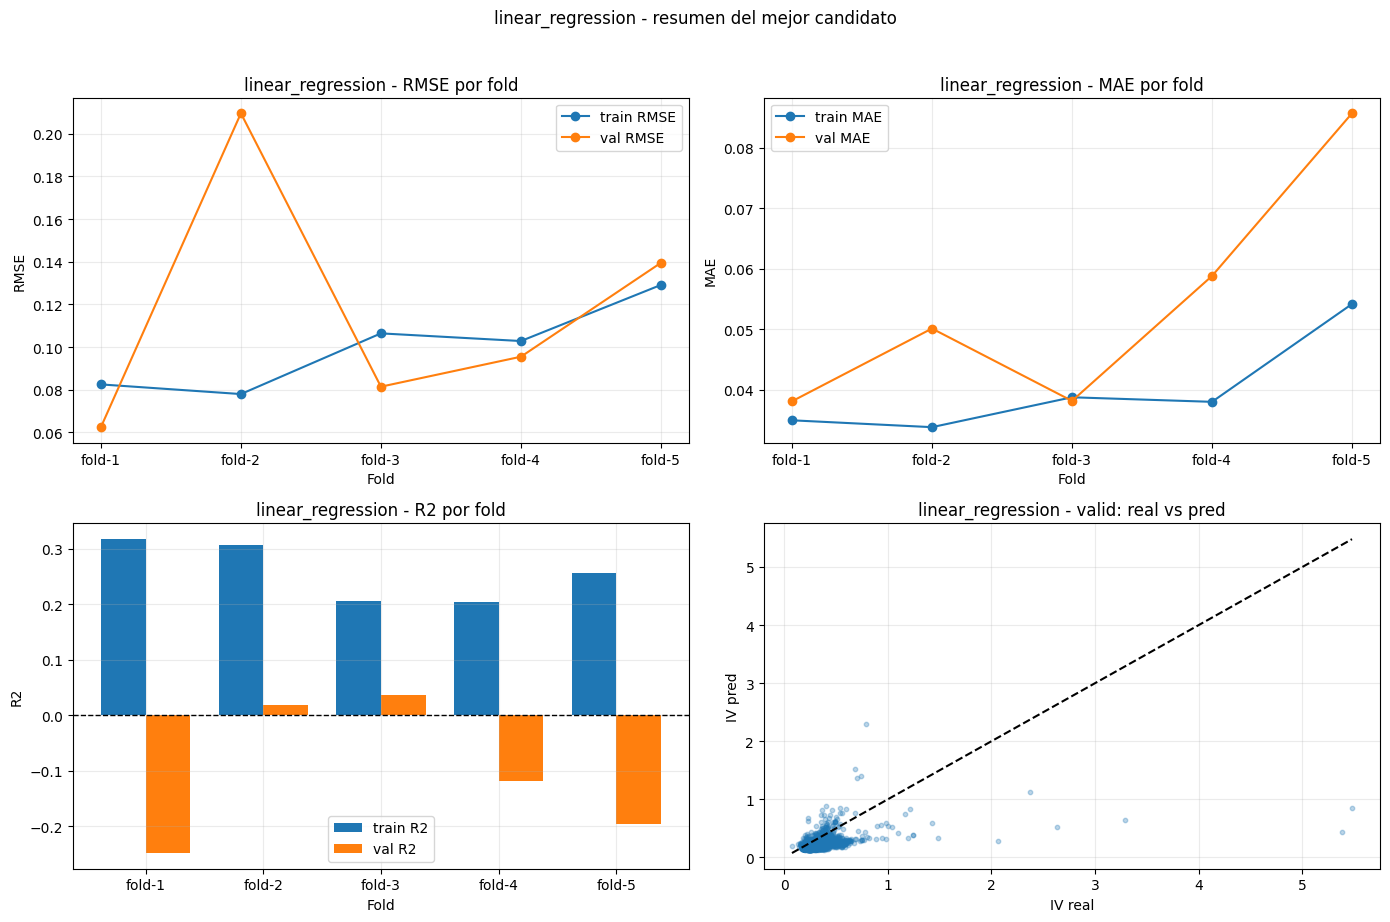

2026-04-13 23:27:41,414 | INFO | src.volatility_models.visualization_utils | Metadata guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\volatility_metadata\family_metadata\linear_regression_metadata.json


In [6]:
linear_models_metrics_table, linear_best_model_name = Trainer(LinearRegressionFamily).run_kfolds_training()

In [3]:
random_forest_models_metrics_table, random_forest_best_model_name = Trainer(RandomForestFamily).run_kfolds_training()

Entrenando familia: random_forest:  38%|███▊      | 45/120 [1:17:38<2:09:24, 103.52s/it]


KeyboardInterrupt: 

Entrenando familia: xgboost: 100%|██████████| 200/200 [1:14:43<00:00, 22.42s/it]
2026-04-14 05:19:01,982 | INFO | src.volatility_models.visualization_utils | Mostrando top 15 modelos de la familia
             custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
xgboost_198       0.104110   0.023675    0.047315  0.834517  0.044138  0.073990  0.566809       0.004941        0.018489      0.074278     0.026536      0.040457    0.214120
xgboost_151       0.105135   0.023457    0.046430  0.840467  0.044583  0.074120  0.566349       0.004921        0.018210      0.072186     0.027020      0.040991    0.214217
xgboost_059       0.105182   0.024505    0.049930  0.815270  0.044678  0.075487  0.551975       0.005019        0.019231      0.082322     0.027527      0.042111    0.223874
xgboost_174       0.105608   0.024211    0.049068  0.821581  0.044510  0.075380  0.553823       0.005070   

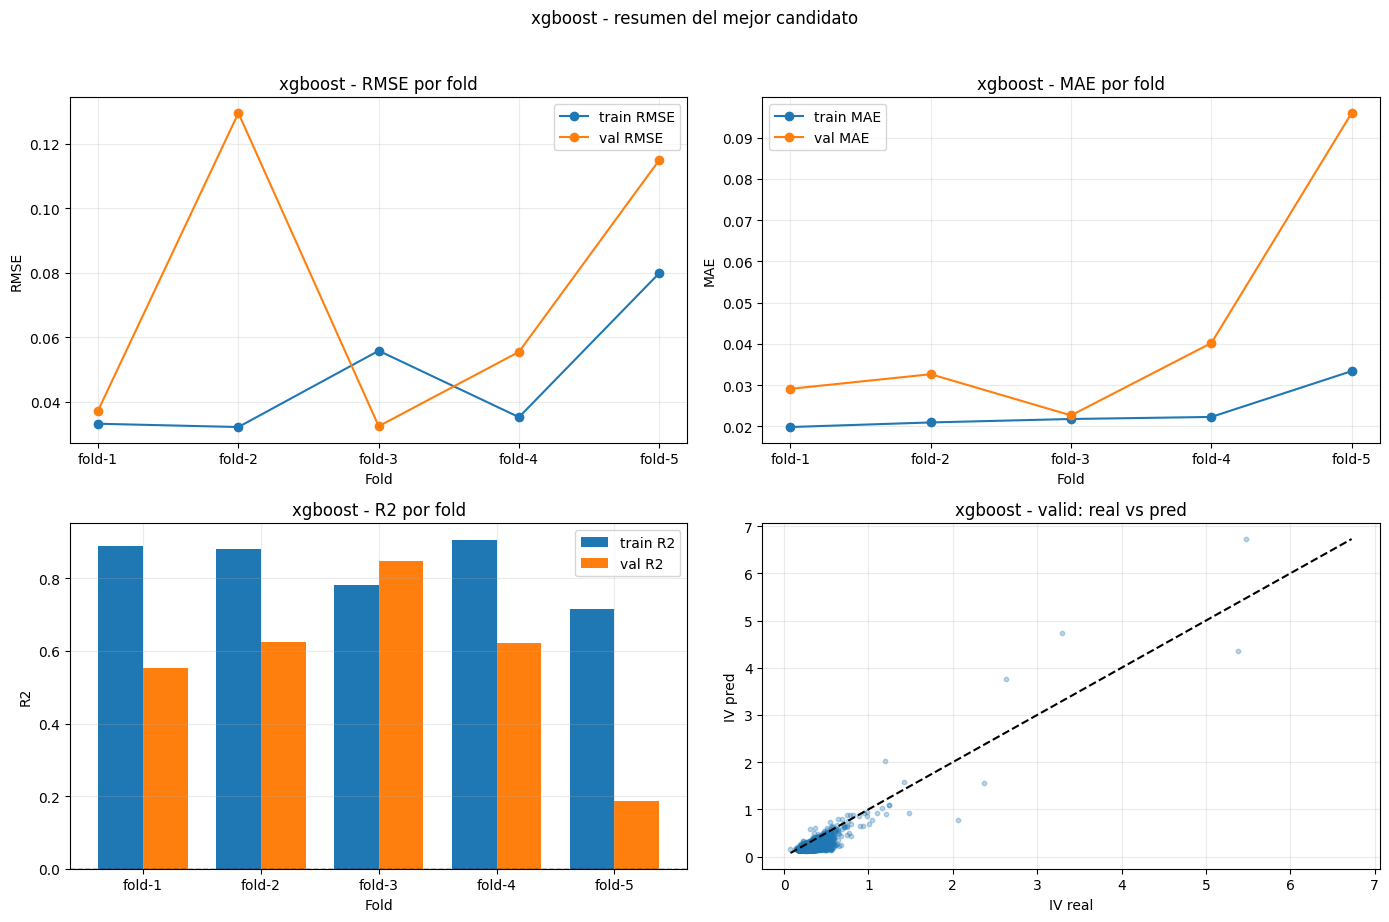

2026-04-14 05:19:48,853 | INFO | src.volatility_models.visualization_utils | Metadata guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\volatility_metadata\family_metadata\xgboost_metadata.json


In [2]:
xgboost_models_metrics_table, xgboost_best_model_name = Trainer(XGBoostFamily).run_kfolds_training()

Entrenando familia: sequential_nn:   0%|          | 0/75 [00:00<?, ?it/s]2026-04-14 07:27:01,485 | WARNING | tensorflow | From c:\Users\danir\Desktop\TFM - Opciones\options-pricing\tfmenv\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

2026-04-14 07:27:01,648 | WARNING | tensorflow | TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
Entrenando familia: sequential_nn: 100%|██████████| 75/75 [10:42:50<00:00, 514.28s/it]  
2026-04-14 18:09:46,410 | INFO | src.volatility_models.visualization_utils | Mostrando top 15 modelos de la familia
                   custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
sequential_nn_051       0

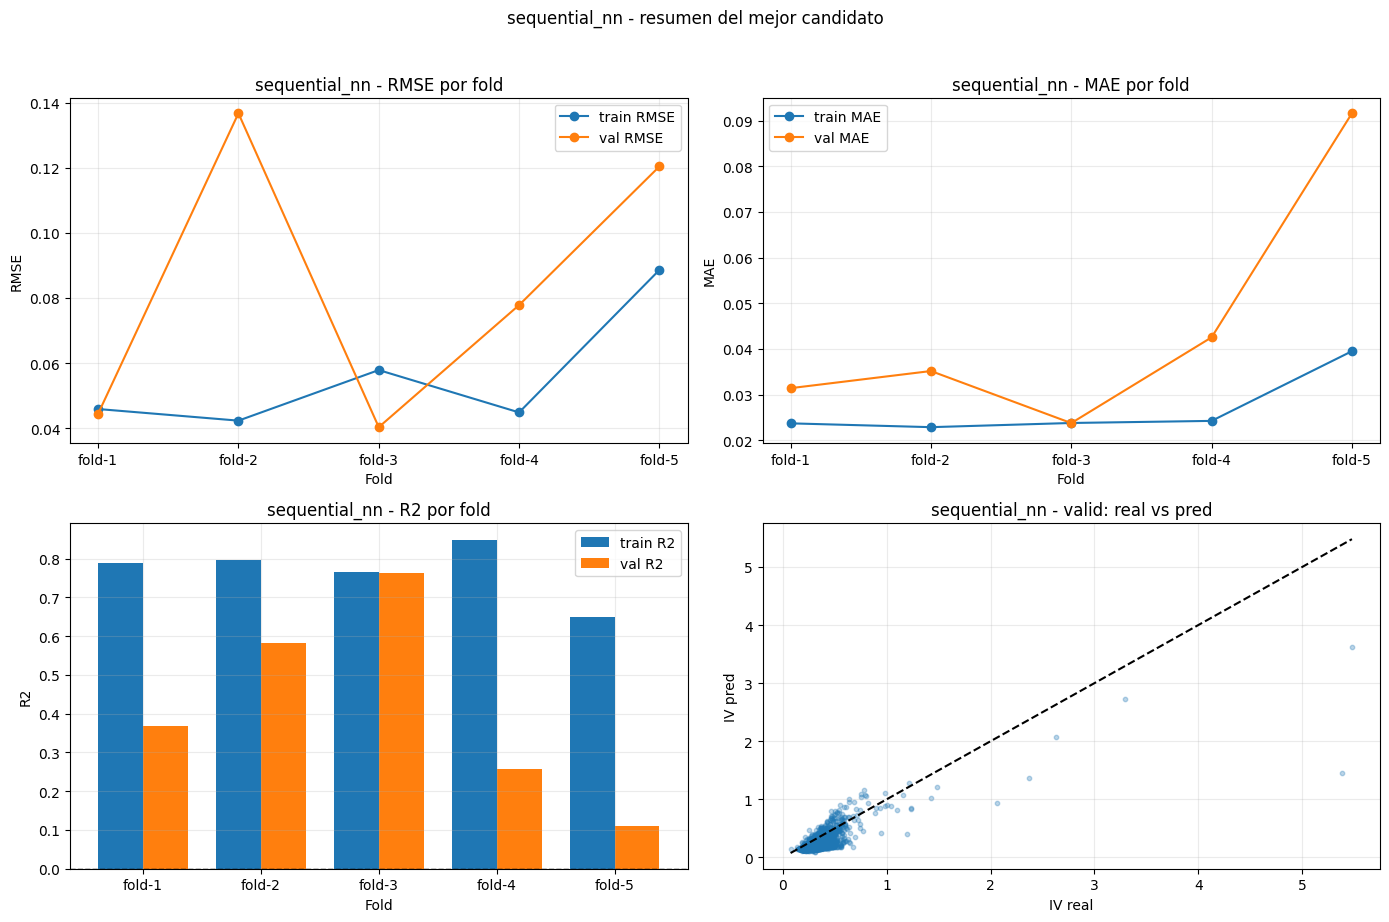

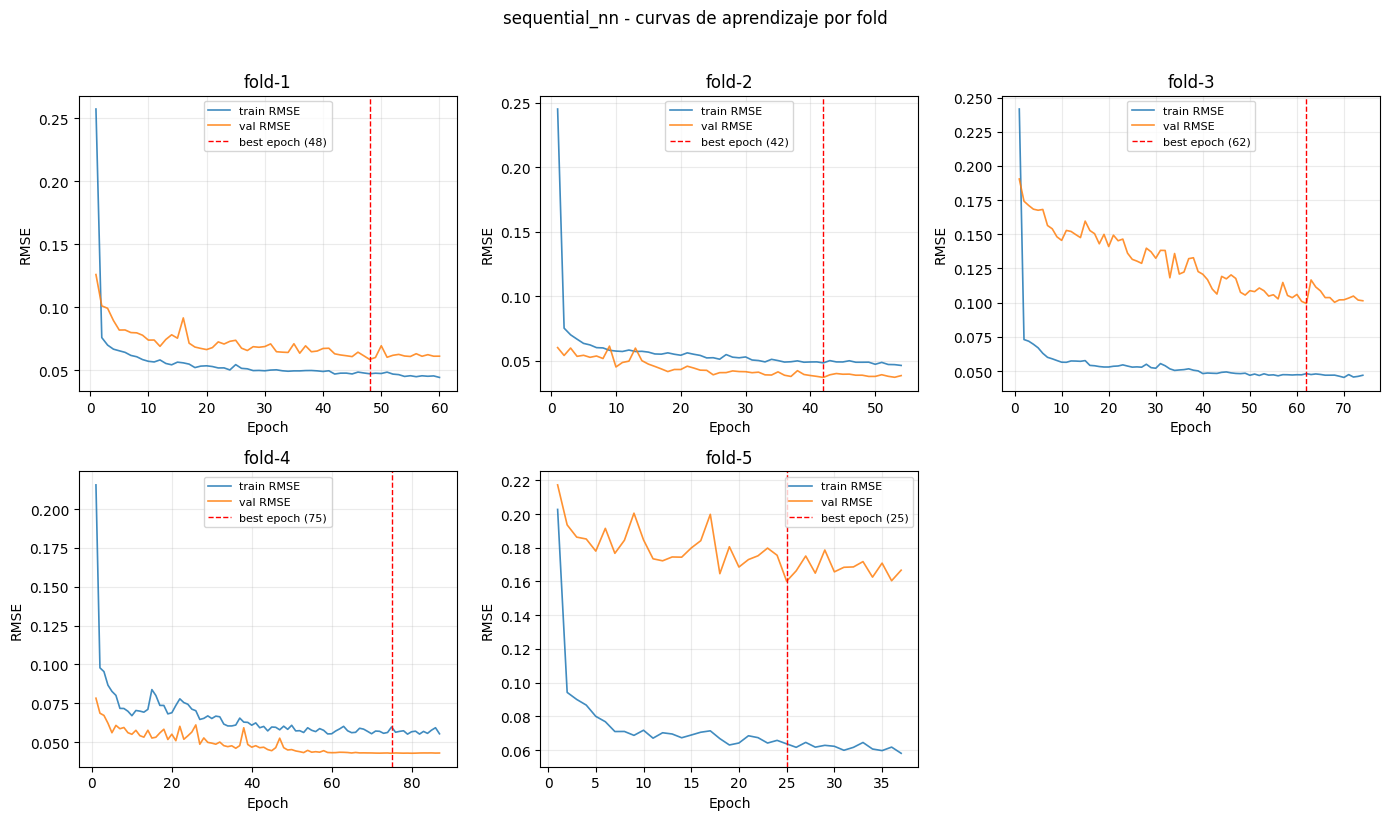

2026-04-14 18:10:04,646 | INFO | src.volatility_models.visualization_utils | Metadata guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\volatility_metadata\family_metadata\sequential_nn_metadata.json


In [2]:
sequential_nn_models_metrics_table, sequential_nn_best_model_name = Trainer(SequentialNNFamily).run_kfolds_training()

# Reentrenamiento de la mejor parametrización de cada familia

In [5]:
linear_best_model_metrics = Trainer(LinearRegressionFamily).retrain_best_params_family()

2026-04-14 19:28:12,459 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento:
                custom_error2  train_mae  train_rmse  train_r2   val_mae  val_rmse     val_r2
retrained_best       0.900853   0.058247    0.129541  0.257994  0.053069   0.54968 -18.444959
2026-04-14 19:28:12,520 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\volatility_metadata\retrained_metadata\linear_regression_train_val_retrained_metadata.json


In [4]:
random_forest_best_model_metrics = Trainer(RandomForestFamily).retrain_best_params_family()

2026-04-14 19:27:57,477 | ERROR | src.volatility_models.visualization_utils | No se encontró metadata para la familia random_forest. Se requiere ejecutar `run_kfolds_training`.
Entrenando familia: random_forest:   0%|          | 0/120 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [6]:
xgboost_best_model_metrics = Trainer(XGBoostFamily).retrain_best_params_family()

2026-04-14 19:29:02,411 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento:
                custom_error2  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2
retrained_best       0.094836   0.041467    0.088158  0.656346  0.046912  0.068809  0.695299
2026-04-14 19:29:02,532 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\volatility_metadata\retrained_metadata\xgboost_train_val_retrained_metadata.json


2026-04-14 19:31:53,411 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento:
                custom_error2  train_mae  train_rmse  train_r2   val_mae  val_rmse     val_r2
retrained_best       2.095948   0.047482    0.100088  0.557049  0.050476  1.224194 -95.446743


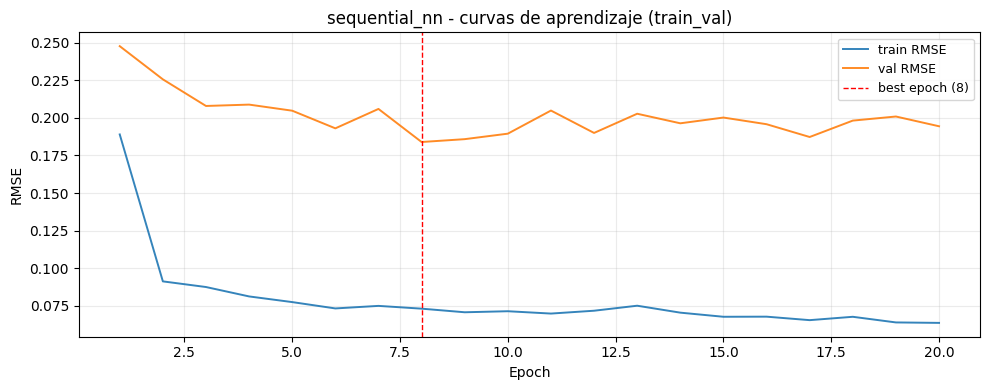

2026-04-14 19:31:53,598 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\volatility_metadata\retrained_metadata\sequential_nn_train_val_retrained_metadata.json


In [7]:
sequential_nn_best_model_metrics = Trainer(SequentialNNFamily).retrain_best_params_family()

# Reentrenamiento para posterior test

In [8]:
linear_best_model_metrics_test = Trainer(LinearRegressionFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST)

2026-04-14 19:32:01,200 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento con train + val:
                train_mae  train_rmse  train_r2  test_mae  test_rmse   test_r2
retrained_best   0.057139    0.129199  0.240124  0.072652   0.187942  0.057637
2026-04-14 19:32:01,287 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\volatility_metadata\retrained_metadata\linear_regression_final_test_retrained_metadata.json
2026-04-14 19:32:01,300 | INFO | src.volatility_models.visualization_utils | Modelo guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\trained_models\linear_regression.joblib


In [ ]:
random_forest_best_model_metrics_test = Trainer(RandomForestFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST)

In [9]:
xgboost_best_model_metrics_test = Trainer(XGBoostFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST)

2026-04-14 19:32:36,016 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento con train + val:
                train_mae  train_rmse  train_r2  test_mae  test_rmse   test_r2
retrained_best   0.038302    0.073973  0.750903  0.065096   0.099448  0.736147
2026-04-14 19:32:36,141 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\volatility_metadata\retrained_metadata\xgboost_final_test_retrained_metadata.json
2026-04-14 19:32:36,162 | INFO | src.volatility_models.visualization_utils | Modelo guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\trained_models\xgboost.joblib


2026-04-14 19:34:26,380 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento con train + val:
                train_mae  train_rmse  train_r2  test_mae  test_rmse  test_r2
retrained_best   0.047328    0.121726  0.325483  0.082671   0.280749 -1.10285


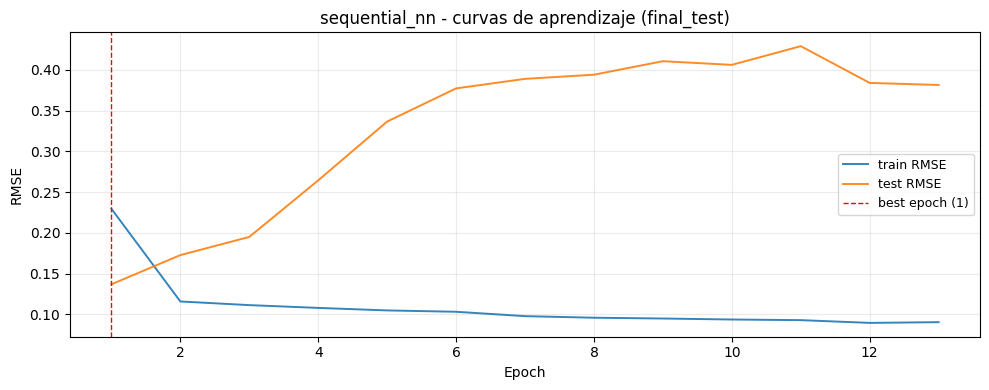

2026-04-14 19:34:26,567 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\volatility_metadata\retrained_metadata\sequential_nn_final_test_retrained_metadata.json
2026-04-14 19:34:26,673 | INFO | src.volatility_models.visualization_utils | Scaler guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\trained_models\sequential_nn_scaler.joblib
2026-04-14 19:34:26,678 | INFO | src.volatility_models.visualization_utils | Modelo guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\trained_models\sequential_nn.keras


In [10]:
sequential_nn_best_model_metrics_test = Trainer(SequentialNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import keras
from keras import layers, regularizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
from tqdm.auto import tqdm
import tempfile
import os
import shutil

from src.volatility_models.data_utils import TrainingDataHandler, BASE_FEATURE_COLS, BASE_NUMERIC_FEATURE_COLS
from src.volatility_models.training_utils import TARGET_COLUMN

# Cargar datos
train_df, val_df, _ = TrainingDataHandler.load_full_features_splitted_data(verbose=False)
train_data = pd.concat([train_df, val_df], ignore_index=True)

X_train = train_data[BASE_FEATURE_COLS].to_numpy(dtype=np.float32)
y_train = train_data[TARGET_COLUMN].to_numpy(dtype=np.float32)

# Escalar features numéricas
scaler = StandardScaler()
numeric_indices = tuple(BASE_FEATURE_COLS.index(col) for col in BASE_NUMERIC_FEATURE_COLS if col in BASE_FEATURE_COLS)
X_train_scaled = X_train.copy()
X_train_scaled[:, numeric_indices] = scaler.fit_transform(X_train[:, numeric_indices])

# Definir HyperModel para búsqueda
class MLPRegressionHyperModel(kt.HyperModel):
    def __init__(self, input_dim):
        self.input_dim = input_dim

    def build(self, hp):
        model = keras.Sequential()
        model.add(layers.Input(shape=(self.input_dim,)))
        
        # Hiperparámetros
        num_layers = hp.Int("num_layers", 1, 4)
        for i in range(num_layers):
            units = hp.Int(f"units_{i}", min_value=32, max_value=512, step=32)
            l2_reg = hp.Float(f"l2_reg_{i}", 1e-5, 1e-3, sampling="log")
            dropout = hp.Float(f"dropout_{i}", 0.0, 0.4, step=0.1)
            
            model.add(layers.Dense(units, kernel_regularizer=regularizers.l2(l2_reg)))
            model.add(layers.BatchNormalization())
            model.add(layers.Activation("relu"))
            if dropout > 0:
                model.add(layers.Dropout(dropout))
        
        model.add(layers.Dense(1, activation="linear"))
        
        lr = hp.Float("learning_rate", 1e-5, 1e-2, sampling="log")
        optimizer = keras.optimizers.Adam(learning_rate=lr)
        model.compile(
            optimizer=optimizer,
            loss="mse",
            metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")],
        )
        
        return model

    def fit(self, hp, model, x, y, validation_data, epochs, callbacks, **kwargs):
        return model.fit(
            x, y,
            validation_data=validation_data,
            epochs=epochs,
            callbacks=callbacks,
            verbose=0,
            **kwargs
        )

# Tuner con barra de progreso real por trial
class RandomSearchWithTqdm(kt.RandomSearch):
    def search(self, *args, **kwargs):
        self._pbar = tqdm(total=self.oracle.max_trials, desc="KerasTuner Trials", unit="trial")
        try:
            return super().search(*args, **kwargs)
        finally:
            self._pbar.close()
            self._pbar = None

    def run_trial(self, trial, *args, **kwargs):
        result = super().run_trial(trial, *args, **kwargs)
        if getattr(self, "_pbar", None) is not None:
            score = trial.score if trial.score is not None else np.nan
            self._pbar.set_postfix({"val_loss": f"{score:.6f}"})
            self._pbar.update(1)
        return result

# Crear directorio temporal
tmp_dir = tempfile.mkdtemp(prefix="keras_tuner_")

# Configurar búsqueda con RandomSearch (garantiza exactamente N trials)
hypermodel = MLPRegressionHyperModel(input_dim=X_train_scaled.shape[1])

tuner = RandomSearchWithTqdm(
    hypermodel,
    objective="val_loss",
    max_trials=200,
    executions_per_trial=1,
    directory=tmp_dir,
    project_name="mLP_search",
    seed=42,
)

# Split train-val interno
X_fit = X_train_scaled[:int(0.8 * len(X_train_scaled))]
y_fit = y_train[:int(0.8 * len(y_train))]
X_val_inner = X_train_scaled[int(0.8 * len(X_train_scaled)): ]
y_val_inner = y_train[int(0.8 * len(y_train)): ]

# Buscar configuraciones
print("Buscando 25 configuraciones de MLP...")
tuner.search(
    X_fit, y_fit,
    validation_data=(X_val_inner, y_val_inner),
    epochs=200,
    batch_size=256,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
    ],
)

# Obtener mejor modelo
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluar en todo train
y_pred = best_model.predict(X_train_scaled, verbose=0).flatten()

mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)

autokeras_best_model_metrics = pd.Series({
    "train_mae": mae,
    "train_mse": mse,
    "train_rmse": rmse,
    "train_r2": r2,
}, name="autokeras_best")

print("\nBúsqueda completada: 25 trials")
print("AutoKeras Best Model Metrics:")
print(autokeras_best_model_metrics)

# Guardar modelo
os.makedirs("trained_models", exist_ok=True)
best_model.save("trained_models/autokeras_best_model.keras")

# Guardar mejor configuración
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nMejor Configuración (Hiperparámetros):")
print(best_hps.values)

# Limpiar temp
shutil.rmtree(tmp_dir, ignore_errors=True)


KerasTuner Trials: 100%|██████████| 2/2 [04:51<00:00, 145.72s/trial, val_loss=nan]


Trial 2 Complete [00h 04m 00s]
val_loss: 0.016331596300005913

Best val_loss So Far: 0.010676310397684574
Total elapsed time: 00h 04m 51s


c:\Users\danir\Desktop\TFM - Opciones\options-pricing\tfmenv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Búsqueda completada: 25 trials
AutoKeras Best Model Metrics:
train_mae     0.039218
train_mse     0.006134
train_rmse    0.078318
train_r2      0.720778
Name: autokeras_best, dtype: float64

Mejor Configuración (Hiperparámetros):
{'num_layers': 3, 'units_0': 32, 'l2_reg_0': 6.562536901904111e-05, 'dropout_0': 0.1, 'learning_rate': 0.004621726369179639, 'units_1': 32, 'l2_reg_1': 1e-05, 'dropout_1': 0.0, 'units_2': 32, 'l2_reg_2': 1e-05, 'dropout_2': 0.0}


In [ ]:
######## CONFIGURACIONES ########
# Configuración de selección del mejor modelo
MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1 = {
    "metric": "custom_error1",
    "mode": "min",
    "alpha": 0.25,
    "beta": 0.75,
    "base_metric": "rmse",
}

# Orden estándar de columnas en la tabla de resultados
METRIC_ORDER = [
    "custom_error1",
    "train_mae",
    "train_rmse",
    "train_r2",
    "valid_mae",
    "valid_rmse",
    "valid_r2",
]

######## MÉTRICAS ########
def calculate_regression_metrics_models(
    y_train_true,
    y_train_pred,
    y_valid_true,
    y_valid_pred,
    round_digits: int = 6,
 ):
    """
    Calcula métricas de regresión para target true y target predicted.

    Retorna un diccionario con las diferentes métricas calculadas y redondeadas
    a `round_digits` decimales.
    """
    y_train_true = np.asarray(y_train_true)
    y_train_pred = np.asarray(y_train_pred)
    y_valid_true = np.asarray(y_valid_true)
    y_valid_pred = np.asarray(y_valid_pred)

    metrics = {
        "train_mae": mean_absolute_error(y_train_true, y_train_pred),
        "train_rmse": np.sqrt(mean_squared_error(y_train_true, y_train_pred)),
        "train_r2": r2_score(y_train_true, y_train_pred),
        "valid_mae": mean_absolute_error(y_valid_true, y_valid_pred),
        "valid_rmse": np.sqrt(mean_squared_error(y_valid_true, y_valid_pred)),
        "valid_r2": r2_score(y_valid_true, y_valid_pred),
    }

    return {k: float(np.round(v, round_digits)) for k, v in metrics.items()}


def calculate_metrics_across_folds(fold_metrics_list, round_digits: int = 6):
    """
    Calcula estadísticas agregadas (media y desviación estándar) de métricas a través de los folds.
    """
    metric_keys = [k for k in METRIC_ORDER if k in fold_metrics_list[0]]
    agg_metrics = {}

    for key in metric_keys:
        values = np.asarray([fm[key] for fm in fold_metrics_list], dtype=float)
        agg_metrics[key] = float(np.round(values.mean(), round_digits))
        agg_metrics[f"{key}_std"] = float(np.round(values.std(), round_digits))

    return agg_metrics


def add_custom_error1(metrics_table: pd.DataFrame, round_digits: int = 6):
    """
    Añade una métrica compuesta de selección que penaliza inestabilidad y sobreajuste.
    """

    base_metric = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1["base_metric"]
    alpha = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1["alpha"]
    beta = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1["beta"]

    train_metric_col = f"train_{base_metric}"
    valid_metric_col = f"valid_{base_metric}"
    valid_metric_std_col = f"{valid_metric_col}_std"

    train_metric = pd.to_numeric(metrics_table[train_metric_col])
    valid_metric = pd.to_numeric(metrics_table[valid_metric_col])
    valid_metric_std = pd.to_numeric(metrics_table[valid_metric_std_col])

    overfit_gap = np.maximum(0.0, valid_metric - train_metric)

    metrics_table = metrics_table.copy()
    metrics_table[MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1["metric"]] = np.round(
        valid_metric + alpha * valid_metric_std + beta * overfit_gap,
        round_digits,
    )

    return metrics_table

def add_model_metrics_row(
    metrics_dict,
    model_name="model",
    metrics_table=None,
    round_digits: int = 6,
):
    """
    Agrega una fila con métricas de un modelo a la tabla comparativa.
    """
    ordered_keys = []
    for k in METRIC_ORDER:
        if k in metrics_dict:
            ordered_keys.append(k)
            if f"{k}_std" in metrics_dict:
                ordered_keys.append(f"{k}_std")

    model_row = pd.DataFrame(
        [{k: float(np.round(metrics_dict[k], round_digits)) for k in ordered_keys}],
        index=[model_name]
    )
    model_row.index.name = "model"

    if metrics_table is None:
        metrics_table = model_row
    else:
        metrics_table = pd.concat([metrics_table, model_row], axis=0)

    metrics_table = add_custom_error1(metrics_table, round_digits=round_digits)

    # Orden de columnas derivado directamente de METRIC_ORDER, con _std intercalado tras cada métrica
    ordered_cols = []
    for k in METRIC_ORDER:
        if k in metrics_table.columns:
            ordered_cols.append(k)
        if f"{k}_std" in metrics_table.columns:
            ordered_cols.append(f"{k}_std")
    ordered_cols += [c for c in metrics_table.columns if c not in ordered_cols]
    metrics_table = metrics_table[ordered_cols]

    selected_metric = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1["metric"]
    selected_mode = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1["mode"]

    if selected_metric in metrics_table.columns:
        metrics_table = metrics_table.sort_values(
            by=selected_metric,
            ascending=(selected_mode == "min")
        )

    return metrics_table


def select_best_model_from_metrics_table(
    metrics_table: pd.DataFrame,
    params_registry=None,
    training_registry=None,
    family_name=None,
    selection_config=None,
):
    """
    Selecciona el mejor modelo desde `metrics_table` según criterio configurable.
    """

    selected_metric = selection_config["metric"]
    selected_mode = selection_config["mode"]

    metric_series = pd.to_numeric(metrics_table[selected_metric])

    best_idx = metric_series.idxmin() if selected_mode == "min" else metric_series.idxmax()
    best_model_row = metrics_table.loc[[best_idx]].copy()

    print(f"Mejor modelo según criterio: {selected_mode}('{selected_metric}') -> {best_idx}")
    display(best_model_row)

    print(params_registry[best_idx])

    best_model_family_graphics(training_registry, best_model_row, family_name)

    return best_model_row


######## GRÁFICAS ########
def best_model_family_graphics(
    training_registry,
    best_model_row,
    family_name=None,
    sample_size: int = 7000,
):
    """
    Gráficas representativas del mejor modelo a lo largo de los folds:
    evolución de métricas train/valid, gap de sobreajuste y scatter agregado real vs pred.
    """

    best_model_name = str(best_model_row.index[0])
    plot_title = family_name if family_name is not None else best_model_name
    fold_keys = sorted(
        [k for k in training_registry.keys() if k.startswith(f"{best_model_name}_fold-")],
        key=lambda x: int(x.split("fold-")[-1]),
    )

    fold_rows = []
    all_valid_true = []
    all_valid_pred = []

    for fold_key in fold_keys:
        record = training_registry[fold_key]
        fold_name = fold_key.split("_")[-1]
        fold_metrics = record["metrics"]

        fold_rows.append(
            {
                "fold": fold_name,
                "train_mae": fold_metrics["train_mae"],
                "train_rmse": fold_metrics["train_rmse"],
                "train_r2": fold_metrics["train_r2"],
                "valid_mae": fold_metrics["valid_mae"],
                "valid_rmse": fold_metrics["valid_rmse"],
                "valid_r2": fold_metrics["valid_r2"],
                "rmse_gap": fold_metrics["valid_rmse"] - fold_metrics["train_rmse"],
            }
        )

        all_valid_true.extend(record["y_valid_true"])
        all_valid_pred.extend(record["y_valid_pred"])

    fold_metrics_df = pd.DataFrame(fold_rows)
    display(fold_metrics_df)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(
        fold_metrics_df["fold"], fold_metrics_df["train_rmse"], marker="o", label="train RMSE"
    )
    axes[0, 0].plot(
        fold_metrics_df["fold"], fold_metrics_df["valid_rmse"], marker="o", label="valid RMSE"
    )
    axes[0, 0].set_title(f"{plot_title} - RMSE por fold")
    axes[0, 0].set_xlabel("Fold")
    axes[0, 0].set_ylabel("RMSE")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.25)

    axes[0, 1].plot(
        fold_metrics_df["fold"], fold_metrics_df["train_mae"], marker="o", label="train MAE"
    )
    axes[0, 1].plot(
        fold_metrics_df["fold"], fold_metrics_df["valid_mae"], marker="o", label="valid MAE"
    )
    axes[0, 1].set_title(f"{plot_title} - MAE por fold")
    axes[0, 1].set_xlabel("Fold")
    axes[0, 1].set_ylabel("MAE")
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.25)

    x = np.arange(len(fold_metrics_df["fold"]))
    width = 0.38
    axes[1, 0].bar(x - width / 2, fold_metrics_df["train_r2"], width=width, label="train R2")
    axes[1, 0].bar(x + width / 2, fold_metrics_df["valid_r2"], width=width, label="valid R2")
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(fold_metrics_df["fold"])
    axes[1, 0].axhline(0.0, color="black", linestyle="--", linewidth=1)
    axes[1, 0].set_title(f"{plot_title} - R2 train vs valid por fold")
    axes[1, 0].set_xlabel("Fold")
    axes[1, 0].set_ylabel("R2")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.25)

    scatter_df = pd.DataFrame(
        {
            "y_true": np.asarray(all_valid_true, dtype=float),
            "y_pred": np.asarray(all_valid_pred, dtype=float),
        }
    )
    if len(scatter_df) > sample_size:
        scatter_df = scatter_df.sample(sample_size, random_state=42)

    min_v = float(min(scatter_df["y_true"].min(), scatter_df["y_pred"].min()))
    max_v = float(max(scatter_df["y_true"].max(), scatter_df["y_pred"].max()))

    axes[1, 1].scatter(scatter_df["y_true"], scatter_df["y_pred"], s=10, alpha=0.30)
    axes[1, 1].plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
    axes[1, 1].set_title(f"{plot_title} - valid agregado: real vs pred")
    axes[1, 1].set_xlabel("IV real")
    axes[1, 1].set_ylabel("IV pred")
    axes[1, 1].grid(alpha=0.25)

    fig.suptitle(f"{plot_title} - resumen del mejor candidato", y=1.02)
    plt.tight_layout()
    plt.show()


## Familias de modelos

En primer lugar, vamos a preparar los sets de datos para el entrenamiento y validación que hay que hacer dentro de cada fold.

In [ ]:
def temporal_inner_split_for_early_stopping(
    X_train,
    y_train,
    valid_fraction: float = 0.20,
    min_valid_samples: int = 256,
):
    """
    Crea un split temporal interno dentro de X_train para el early stopping.
    El fold-valid externo queda reservado únicamente para evaluación final de métricas,
    evitando así cualquier sesgo de overfitting hacia ese conjunto.
    """
    n_samples = len(X_train)

    n_valid = max(int(np.ceil(n_samples * valid_fraction)), min_valid_samples)
    split_idx = n_samples - n_valid

    return X_train[:split_idx], y_train[:split_idx], X_train[split_idx:], y_train[split_idx:]


def prepare_training_fold_data(train_df: pd.DataFrame, fold_info):
    """
    Prepara X/y de train y valid para un fold temporal.

    Se asume siempre este formato de entrada:
    ("fold-1", {"train_dates": [...], "valid_dates": [...]})
    """
    fold_name, fold_dates = fold_info
    fold_train_dates = fold_dates["train_dates"]
    fold_valid_dates = fold_dates["valid_dates"]

    train_exec_dates = train_df[VolatilityDBEnum.EXEC_DATETIME].dt.date

    fold_train_df = train_df[train_exec_dates.isin(fold_train_dates)].copy()
    fold_valid_df = train_df[train_exec_dates.isin(fold_valid_dates)].copy()

    if len(fold_train_df) == 0 or len(fold_valid_df) == 0:
        raise ValueError(
            f"{fold_name}: fold vacio tras filtrar fechas o nulos. "
            "Revisa train_dates/valid_dates y calidad de datos."
        )

    X_train_fold = fold_train_df[BASE_FEATURE_COLS].to_numpy(dtype=float)
    y_train_fold = fold_train_df[TARGET_COL].to_numpy(dtype=float)
    X_valid_fold = fold_valid_df[BASE_FEATURE_COLS].to_numpy(dtype=float)
    y_valid_fold = fold_valid_df[TARGET_COL].to_numpy(dtype=float)

    return X_train_fold, y_train_fold, X_valid_fold, y_valid_fold


def build_model_candidates(
    fixed_params,
    search_space=None,
    model_prefix="model",
    n_iter=40,
    seed=42,
 ):
    """
    Construye candidatos de una familia a partir de parámetros fijos y un espacio de búsqueda opcional.

    Si `search_space` está vacío o es `None`, devuelve un único modelo con `fixed_params`.
    """
    if not search_space:
        return {model_prefix: fixed_params.copy()}

    rng = np.random.default_rng(seed)
    models = {}

    for i in range(n_iter):
        sampled = {}
        for param_name, values in search_space.items():
            values_list = list(values)
            sampled_value = values_list[int(rng.integers(0, len(values_list)))]
            sampled[param_name] = sampled_value

        models[f"{model_prefix}_{i+1:03d}"] = {**fixed_params, **sampled}

    return models


# ==============================
# Persistencia de metadatos
# ==============================
FAMILY_METADATA_DIR = Path("artifacts") / "family_metadata"
FAMILY_METADATA_DIR.mkdir(parents=True, exist_ok=True)
USE_SAVED_FAMILY_METADATA = True


def _to_builtin(obj):
    """Convierte tipos numpy/pandas a tipos nativos para serializar en JSON."""
    if isinstance(obj, dict):
        return {str(k): _to_builtin(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_to_builtin(v) for v in obj]
    if isinstance(obj, tuple):
        return [_to_builtin(v) for v in obj]
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def _training_registry_for_json(training_registry: dict) -> dict:
    """Elimina objetos no serializables (p.ej. modelos) y conserva métricas/históricos."""
    serializable = {}
    for key, record in training_registry.items():
        serializable[key] = {
            "best_iteration": _to_builtin(record.get("best_iteration", None)),
            "best_score": _to_builtin(record.get("best_score", None)),
            "metrics": _to_builtin(record.get("metrics", {})),
            "epoch_history": _to_builtin(record.get("epoch_history", {})),
            "y_valid_true": _to_builtin(record.get("y_valid_true", [])),
            "y_valid_pred": _to_builtin(record.get("y_valid_pred", [])),
        }
    return serializable


def save_family_metadata(
    family_key: str,
    family_name: str,
    metrics_table: pd.DataFrame,
    model_params_registry: dict,
    training_registry: dict,
    best_model_row: pd.DataFrame,
):
    """Guarda metadatos de una familia para reanudar trabajo en otra sesión."""
    if metrics_table is None or len(metrics_table) == 0:
        raise ValueError(f"{family_key}: metrics_table vacío, no se puede persistir metadata.")

    best_model_name = str(best_model_row.index[0])
    best_model_metrics = {
        k: _to_builtin(v) for k, v in best_model_row.iloc[0].to_dict().items()
    }

    payload = {
        "family_key": family_key,
        "family_name": family_name,
        "best_model_name": best_model_name,
        "best_model_metrics": best_model_metrics,
        "best_model_params": _to_builtin(model_params_registry[best_model_name]),
        "metrics_table": _to_builtin(metrics_table.to_dict(orient="split")),
        "model_params_registry": _to_builtin(model_params_registry),
        "training_registry": _training_registry_for_json(training_registry),
    }

    file_path = FAMILY_METADATA_DIR / f"{family_key}_metadata.json"
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

    print(f"Metadata guardada: {file_path}")


def load_family_metadata(family_key: str):
    """Carga metadatos de una familia. Retorna None si no existe."""
    file_path = FAMILY_METADATA_DIR / f"{family_key}_metadata.json"
    if not file_path.exists():
        return None

    with open(file_path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    return payload


def restore_family_from_metadata(payload: dict):
    """Reconstruye estructuras en memoria desde metadata serializada."""
    metrics_table = pd.DataFrame(
        data=payload["metrics_table"]["data"],
        columns=payload["metrics_table"]["columns"],
        index=payload["metrics_table"]["index"],
    )
    best_model_name = payload["best_model_name"]
    best_model_row = pd.DataFrame([payload["best_model_metrics"]], index=[best_model_name])

    return {
        "metrics_table": metrics_table,
        "model_params_registry": payload["model_params_registry"],
        "training_registry": payload["training_registry"],
        "best_model_row": best_model_row,
        "best_model_name": best_model_name,
        "best_model_params": payload["best_model_params"],
    }

In [ ]:
fold_data_cache = []
for j_fold in range(n_folds):
    fold_name = f"fold-{j_fold+1}"
    X_train_fold, y_train_fold, X_valid_fold, y_valid_fold = prepare_training_fold_data(
        train_df, folds_dates_dict[j_fold]
    )
    fold_data_cache.append((fold_name, X_train_fold, y_train_fold, X_valid_fold, y_valid_fold))

### Lineal

Se va a probar con los siguientes:
* LinearRegression
* ElasticNetCV
* HuberRegression

In [ ]:
### Linear Regression ###
LINEAR_FIXED_PARAMS = {
    "fit_intercept": True,
    "copy_X": True,
    "n_jobs": None,
    "positive": False,
}

LINEAR_SEARCH_SPACE = {}

LINEAR_REGRESSION_CONFIG = {
    "family_name": "Linear Regression",
    "models": build_model_candidates(
        fixed_params=LINEAR_FIXED_PARAMS,
        search_space=LINEAR_SEARCH_SPACE,
        model_prefix="linear_regression",
        n_iter=1,
        seed=42,
    ),
}

linear_family_key = "linear"
linear_meta = load_family_metadata(linear_family_key) if USE_SAVED_FAMILY_METADATA else None

if linear_meta is not None:
    restored = restore_family_from_metadata(linear_meta)

    family_models_metrics_table = restored["metrics_table"]
    model_params_registry = restored["model_params_registry"]
    training_registry = restored["training_registry"]
    best_model_linear = restored["best_model_row"]

    linear_best_name = restored["best_model_name"]
    linear_best_params = restored["best_model_params"]

    print("Metadata cargada para Linear Regression")
    display(best_model_linear)

    # Mostrar gráficas también al cargar desde metadata
    best_model_family_graphics(
        training_registry,
        best_model_linear,
        family_name=LINEAR_REGRESSION_CONFIG["family_name"],
    )
else:
    total_family_models = len(LINEAR_REGRESSION_CONFIG["models"])
    family_models_metrics_table = None
    training_registry = {}
    model_params_registry = {}

    for model_i_name, model_i_params in tqdm(
        LINEAR_REGRESSION_CONFIG["models"].items(),
        total=total_family_models,
        desc=f"Entrenando familia: {LINEAR_REGRESSION_CONFIG['family_name']}",
    ):
        model_i_folds_metrics = []
        model_params_registry[model_i_name] = model_i_params

        for fold_name, X_train_fold, y_train_fold, X_valid_fold, y_valid_fold in fold_data_cache:
            linear_model = LinearRegression(**model_i_params)
            linear_model.fit(X_train_fold, y_train_fold)

            y_train_fold_pred = linear_model.predict(X_train_fold)
            y_valid_fold_pred = linear_model.predict(X_valid_fold)

            fold_metrics = calculate_regression_metrics_models(
                y_train_fold, y_train_fold_pred, y_valid_fold, y_valid_fold_pred
            )
            model_i_folds_metrics.append((fold_name, fold_metrics))

            training_registry[f"{model_i_name}_{fold_name}"] = {
                "model": linear_model,
                "best_iteration": None,
                "best_score": np.nan,
                "metrics": fold_metrics,
                "y_valid_true": y_valid_fold.tolist(),
                "y_valid_pred": y_valid_fold_pred.tolist(),
            }

        metrics = calculate_metrics_across_folds([m for _, m in model_i_folds_metrics])
        family_models_metrics_table = add_model_metrics_row(
            metrics,
            model_name=model_i_name,
            metrics_table=family_models_metrics_table,
        )

    print("\n" + "=" * 95)
    print(f"Metricas de la familia de modelos: {LINEAR_REGRESSION_CONFIG['family_name']}")
    display(family_models_metrics_table.head(15))
    print("=" * 95)

    best_model_linear = select_best_model_from_metrics_table(
        family_models_metrics_table,
        model_params_registry,
        training_registry,
        family_name=LINEAR_REGRESSION_CONFIG["family_name"],
        selection_config=MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1,
    )

    linear_best_name = str(best_model_linear.index[0])
    linear_best_params = model_params_registry[linear_best_name].copy()

    save_family_metadata(
        family_key=linear_family_key,
        family_name=LINEAR_REGRESSION_CONFIG["family_name"],
        metrics_table=family_models_metrics_table,
        model_params_registry=model_params_registry,
        training_registry=training_registry,
        best_model_row=best_model_linear,
    )

Para este modelo lineal no se pueden tunear hiperparámetros, por lo que se tiene un único modelo a probar.

### Random Forest

In [ ]:
### Random Forest ###
RF_FIXED_PARAMS = {
    "criterion": "squared_error",
    "random_state": 42,
    "n_jobs": -1,
    "min_weight_fraction_leaf": 0.0,
    "verbose": 0,
    "bootstrap": True,
}

RF_SEARCH_SPACE = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [None, 8, 12, 16, 24, 32],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [1.0, "sqrt", "log2", 0.7, 0.5],
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 0.9],
    "min_impurity_decrease": [0.0, 1e-6, 1e-5, 1e-4],
    "ccp_alpha": [0.0, 1e-6, 1e-5, 1e-4],
}

RANDOM_FOREST_CONFIG = {
    "family_name": "Random Forest",
    "models": build_model_candidates(
        fixed_params=RF_FIXED_PARAMS,
        search_space=RF_SEARCH_SPACE,
        model_prefix="rf_rs",
        n_iter=120,
        seed=42,
    ),
}

rf_family_key = "random_forest"
rf_meta = load_family_metadata(rf_family_key) if USE_SAVED_FAMILY_METADATA else None

if rf_meta is not None:
    restored = restore_family_from_metadata(rf_meta)

    family_models_metrics_table = restored["metrics_table"]
    model_params_registry = restored["model_params_registry"]
    training_registry = restored["training_registry"]
    best_model_rf = restored["best_model_row"]

    rf_best_name = restored["best_model_name"]
    rf_best_params = restored["best_model_params"]

    print("Metadata cargada para Random Forest")
    display(best_model_rf)

    # Mostrar gráficas también al cargar desde metadata
    best_model_family_graphics(
        training_registry,
        best_model_rf,
        family_name=RANDOM_FOREST_CONFIG["family_name"],
    )
else:
    total_family_models = len(RANDOM_FOREST_CONFIG["models"])
    family_models_metrics_table = None
    training_registry = {}
    model_params_registry = {}

    for model_i_name, model_i_params in tqdm(
        RANDOM_FOREST_CONFIG["models"].items(),
        total=total_family_models,
        desc=f"Entrenando familia: {RANDOM_FOREST_CONFIG['family_name']}",
    ):
        model_i_folds_metrics = []
        model_params_registry[model_i_name] = model_i_params

        for fold_name, X_train_fold, y_train_fold, X_valid_fold, y_valid_fold in fold_data_cache:
            rf_model = RandomForestRegressor(**model_i_params)
            rf_model.fit(X_train_fold, y_train_fold)

            y_train_fold_pred = rf_model.predict(X_train_fold)
            y_valid_fold_pred = rf_model.predict(X_valid_fold)

            fold_metrics = calculate_regression_metrics_models(
                y_train_fold, y_train_fold_pred, y_valid_fold, y_valid_fold_pred
            )
            model_i_folds_metrics.append((fold_name, fold_metrics))

            training_registry[f"{model_i_name}_{fold_name}"] = {
                "model": rf_model,
                "best_iteration": None,
                "best_score": np.nan,
                "metrics": fold_metrics,
                "y_valid_true": y_valid_fold.tolist(),
                "y_valid_pred": y_valid_fold_pred.tolist(),
            }

        metrics = calculate_metrics_across_folds([m for _, m in model_i_folds_metrics])
        family_models_metrics_table = add_model_metrics_row(
            metrics,
            model_name=model_i_name,
            metrics_table=family_models_metrics_table,
        )

    print("\n" + "=" * 95)
    print(f"Metricas de la familia de modelos: {RANDOM_FOREST_CONFIG['family_name']}")
    display(family_models_metrics_table.head(15))
    print("=" * 95)

    best_model_rf = select_best_model_from_metrics_table(
        family_models_metrics_table,
        model_params_registry,
        training_registry,
        family_name=RANDOM_FOREST_CONFIG["family_name"],
        selection_config=MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1,
    )

    rf_best_name = str(best_model_rf.index[0])
    rf_best_params = model_params_registry[rf_best_name].copy()

    save_family_metadata(
        family_key=rf_family_key,
        family_name=RANDOM_FOREST_CONFIG["family_name"],
        metrics_table=family_models_metrics_table,
        model_params_registry=model_params_registry,
        training_registry=training_registry,
        best_model_row=best_model_rf,
    )

### XGBoost

In [ ]:
### XGBoost ###

XGB_FIXED_PARAMS = {
    "booster": "gbtree",
    "objective": "reg:pseudohubererror",
    "eval_metric": "rmse",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist",
    "predictor": "auto",
    "enable_categorical": False,
    "verbosity": 0,
    "sampling_method": "uniform",
    "colsample_bylevel": 1.0,
    "colsample_bynode": 1.0,
    "max_delta_step": 0.0,
    "grow_policy": "depthwise",
    "base_score": 0.20,  # Ajustado a la media del target para mejorar convergencia
}

XGB_SEARCH_SPACE = {
    "n_estimators": [400, 600, 800, 1000, 1400],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 8, 10, 15, 20],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0.0, 0.05, 0.1, 0.2, 0.3, 0.5],
    "reg_alpha": [0.0, 0.01, 0.05, 0.1, 0.2, 0.5],
    "reg_lambda": [0.5, 1.0, 1.5, 2.0, 3.0],
    "max_bin": [128, 256, 512],
    "num_parallel_tree": [1, 2, 4],
    "early_stopping_rounds": [30, 50, 80],
}

XGBOOST_CONFIG = {
    "family_name": "XGBoost",
    "models": build_model_candidates(
        fixed_params=XGB_FIXED_PARAMS,
        search_space=XGB_SEARCH_SPACE,
        model_prefix="xgb_rs",
        n_iter=200,
        seed=42,
    ),
}

xgb_family_key = "xgboost"
xgb_meta = load_family_metadata(xgb_family_key) if USE_SAVED_FAMILY_METADATA else None

if xgb_meta is not None:
    restored = restore_family_from_metadata(xgb_meta)

    family_models_metrics_table = restored["metrics_table"]
    model_params_registry = restored["model_params_registry"]
    training_registry = restored["training_registry"]
    best_model_xgb = restored["best_model_row"]

    xgb_best_name = restored["best_model_name"]
    xgb_best_params = restored["best_model_params"]

    print("Metadata cargada para XGBoost")
    display(best_model_xgb)

    # Mostrar gráficas también al cargar desde metadata
    best_model_family_graphics(
        training_registry,
        best_model_xgb,
        family_name=XGBOOST_CONFIG["family_name"],
    )
else:
    total_family_models = len(XGBOOST_CONFIG["models"])
    family_models_metrics_table = None
    training_registry = {}
    model_params_registry = {}

    for model_i_name, model_i_params in tqdm(
        XGBOOST_CONFIG["models"].items(),
        total=total_family_models,
        desc=f"Entrenando familia: {XGBOOST_CONFIG['family_name']}",
    ):
        model_i_folds_metrics = []
        model_params_registry[model_i_name] = model_i_params

        for fold_name, X_train_fold, y_train_fold, X_valid_fold, y_valid_fold in fold_data_cache:
            X_fit, y_fit, X_es, y_es = temporal_inner_split_for_early_stopping(
                X_train_fold, y_train_fold
            )

            xgb_model = XGBRegressor(**model_i_params)
            xgb_model.fit(
                X_fit,
                y_fit,
                eval_set=[(X_es, y_es)],
                verbose=False,
            )

            y_train_fold_pred = xgb_model.predict(X_train_fold)
            y_valid_fold_pred = xgb_model.predict(X_valid_fold)

            fold_metrics = calculate_regression_metrics_models(
                y_train_fold, y_train_fold_pred, y_valid_fold, y_valid_fold_pred
            )
            model_i_folds_metrics.append((fold_name, fold_metrics))

            training_registry[f"{model_i_name}_{fold_name}"] = {
                "model": xgb_model,
                "best_iteration": int(getattr(xgb_model, "best_iteration", -1)),
                "best_score": float(getattr(xgb_model, "best_score", np.nan)),
                "metrics": fold_metrics,
                "y_valid_true": y_valid_fold.tolist(),
                "y_valid_pred": y_valid_fold_pred.tolist(),
            }

        metrics = calculate_metrics_across_folds([m for _, m in model_i_folds_metrics])
        family_models_metrics_table = add_model_metrics_row(
            metrics,
            model_name=model_i_name,
            metrics_table=family_models_metrics_table,
        )

    print("\n" + "=" * 95)
    print(f"Metricas de la familia de modelos: {XGBOOST_CONFIG['family_name']}")
    display(family_models_metrics_table.head(15))
    print("=" * 95)

    best_model_xgb = select_best_model_from_metrics_table(
        family_models_metrics_table,
        model_params_registry,
        training_registry,
        family_name=XGBOOST_CONFIG["family_name"],
        selection_config=MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1,
    )

    xgb_best_name = str(best_model_xgb.index[0])
    xgb_best_params = model_params_registry[xgb_best_name].copy()

    save_family_metadata(
        family_key=xgb_family_key,
        family_name=XGBOOST_CONFIG["family_name"],
        metrics_table=family_models_metrics_table,
        model_params_registry=model_params_registry,
        training_registry=training_registry,
        best_model_row=best_model_xgb,
    )

### Redes Neuronales Secuenciales (MLP)

In [ ]:
### Redes Neuronales Secuenciales (MLP) ###

def scale_only_numeric_features(
    X_fit_raw,
    X_es_raw,
    X_train_full_raw,
    X_valid_raw,
    numeric_col_indices,
):
    """
    Escala solo las columnas identificadas por numeric_col_indices y deja intactas las categóricas.
    El scaler se ajusta únicamente sobre X_fit_raw para evitar cualquier data leakage.
    """
    scaler = StandardScaler()
    idx = list(numeric_col_indices)

    X_fit_scaled = X_fit_raw.copy()
    X_fit_scaled[:, idx] = scaler.fit_transform(X_fit_raw[:, idx])

    X_es_scaled = X_es_raw.copy()
    X_es_scaled[:, idx] = scaler.transform(X_es_raw[:, idx])
    
    X_train_full_scaled = X_train_full_raw.copy()
    X_train_full_scaled[:, idx] = scaler.transform(X_train_full_raw[:, idx])

    X_valid_scaled = X_valid_raw.copy()
    X_valid_scaled[:, idx] = scaler.transform(X_valid_raw[:, idx])

    return X_fit_scaled, X_es_scaled, X_train_full_scaled, X_valid_scaled


def build_sequential_nn_model(params: dict, input_dim: int):
    """Construye una MLP secuencial a partir del dict de hiperparámetros."""
    tf.random.set_seed(42)

    hidden_layers = params["hidden_layers"]
    l2_reg = params["l2_reg"]
    learning_rate = params["learning_rate"]
    activation = params["activation"]
    dropout_rate = params["dropout_rate"]
    use_batch_norm = params["use_batch_norm"]
    kernel_initializer = params["kernel_initializer"]
    loss = params["loss"]

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(layers.Dense(
            units,
            activation=None,
            kernel_initializer=kernel_initializer,
            kernel_regularizer=regularizers.l2(l2_reg),
        ))

        if use_batch_norm:
            model.add(layers.BatchNormalization())

        model.add(layers.Activation(activation))

        if dropout_rate > 0.0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="linear"))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
    )

    return model


def plot_nn_learning_curves(training_registry, best_model_row, family_name=None):
    """
    Muestra las curvas de aprendizaje (train RMSE vs val RMSE por epoch) del mejor modelo
    en cada fold, con una línea vertical en el early-stopping point.
    """
    best_model_name = str(best_model_row.index[0])
    plot_title = family_name

    fold_keys = sorted(
        [k for k in training_registry.keys() if k.startswith(f"{best_model_name}_fold-")],
        key=lambda x: int(x.split("fold-")[-1]),
    )

    n_folds = len(fold_keys)
    n_cols = 3
    n_rows = int(np.ceil(n_folds / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax_idx, fold_key in enumerate(fold_keys):
        ax = axes_flat[ax_idx]
        record = training_registry[fold_key]
        fold_name = fold_key.split("_")[-1]
        epoch_history = record.get("epoch_history", {})

        val_rmse = epoch_history.get("val_rmse", [])
        train_rmse = epoch_history.get("rmse", [])
        best_epoch = record.get("best_iteration", None)

        epochs = range(1, len(val_rmse) + 1)

        if train_rmse:
            ax.plot(epochs, train_rmse, label="train RMSE", linewidth=1.2, alpha=0.85)
        ax.plot(epochs, val_rmse, label="val RMSE", linewidth=1.2, alpha=0.85)

        if best_epoch and best_epoch <= len(val_rmse):
            ax.axvline(
                best_epoch, color="red", linestyle="--", linewidth=1,
                label=f"best epoch ({best_epoch})"
            )

        ax.set_title(fold_name)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("RMSE")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)

    for ax_idx in range(n_folds, len(axes_flat)):
        axes_flat[ax_idx].set_visible(False)

    fig.suptitle(f"{plot_title} - curvas de aprendizaje por fold", y=1.02)
    plt.tight_layout()
    plt.show()


NN_FIXED_PARAMS = {
    "patience": 12,
    "epochs": 150,
    "verbose": 0,
}

NN_SEARCH_SPACE = {
    "hidden_layers": [
        [32],
        [64],
        [128],
        [256],
        [512],
        [32, 32],
        [64, 32],
        [64, 64],
        [128, 64],
        [128, 128],
        [256, 128],
        [256, 256],
        [128, 64, 32],
        [128, 128, 64],
        [128, 128, 128],
        [256, 128, 64],
        [256, 256, 128],
        [256, 128, 64, 32],
        [256, 256, 128, 64],
        [512, 256, 128, 64],
    ],
    "dropout_rate": [0.0, 0.05, 0.1, 0.2, 0.3],
    "l2_reg": [0.0, 1e-5, 1e-4, 5e-4, 1e-3],
    "learning_rate": [5e-5, 1e-4, 5e-4, 1e-3, 3e-3],
    "batch_size": [128, 256, 512, 1024, 2048],
    "activation": ["relu", "gelu"],
    "kernel_initializer": ["he_normal", "he_uniform"],
    "use_batch_norm": [True, False],
    "use_lr_scheduler": [True, False],
    "loss": ["huber", "mse"],
}

NN_SEQ_CONFIG = {
    "family_name": "Sequential NN",
    "models": build_model_candidates(
        fixed_params=NN_FIXED_PARAMS,
        search_space=NN_SEARCH_SPACE,
        model_prefix="nn_seq_rs",
        n_iter=75,
        seed=42,
    ),
}

# Índices de columnas numéricas calculados por nombre desde BASE_FEATURE_COLS
NUMERIC_COL_INDICES = [BASE_FEATURE_COLS.index(col) for col in BASE_NUMERIC_FEATURE_COLS]

nn_family_key = "sequential_nn"
nn_meta = load_family_metadata(nn_family_key) if USE_SAVED_FAMILY_METADATA else None

if nn_meta is not None:
    restored = restore_family_from_metadata(nn_meta)

    family_models_metrics_table = restored["metrics_table"]
    model_params_registry = restored["model_params_registry"]
    training_registry = restored["training_registry"]
    best_model_nn_seq = restored["best_model_row"]

    nn_seq_best_name = restored["best_model_name"]
    nn_seq_best_params = restored["best_model_params"]

    print("Metadata cargada para Sequential NN")
    display(best_model_nn_seq)

    # Mostrar gráficas también al cargar desde metadata
    best_model_family_graphics(
        training_registry,
        best_model_nn_seq,
        family_name=NN_SEQ_CONFIG["family_name"],
    )
else:
    total_family_models = len(NN_SEQ_CONFIG["models"])
    family_models_metrics_table = None
    training_registry = {}
    model_params_registry = {}

    for model_i_name, model_i_params in tqdm(
        NN_SEQ_CONFIG["models"].items(),
        total=total_family_models,
        desc=f"Entrenando familia: {NN_SEQ_CONFIG['family_name']}",
    ):
        model_i_folds_metrics = []
        model_params_registry[model_i_name] = model_i_params

        for fold_name, X_train_fold, y_train_fold, X_valid_fold, y_valid_fold in fold_data_cache:
            X_fit_raw, y_fit, X_es_raw, y_es = temporal_inner_split_for_early_stopping(
                X_train_fold, y_train_fold
            )

            X_fit_scaled, X_es_scaled, X_train_full_scaled, X_valid_scaled = scale_only_numeric_features(
                X_fit_raw, X_es_raw, X_train_fold, X_valid_fold, NUMERIC_COL_INDICES
            )

            keras.backend.clear_session()
            nn_model = build_sequential_nn_model(model_i_params, input_dim=X_fit_scaled.shape[1])

            early_stop = EarlyStopping(
                monitor="val_rmse",
                mode="min",
                patience=model_i_params["patience"],
                restore_best_weights=True,
                verbose=0,
            )

            callbacks = [early_stop]

            if model_i_params.get("use_lr_scheduler", False):
                callbacks.append(
                    ReduceLROnPlateau(
                        monitor="val_rmse",
                        factor=0.5,
                        patience=5,
                        min_lr=1e-6,
                        verbose=0,
                    )
                )

            history = nn_model.fit(
                X_fit_scaled,
                y_fit,
                epochs=model_i_params["epochs"],
                batch_size=model_i_params["batch_size"],
                validation_data=(X_es_scaled, y_es),
                callbacks=callbacks,
                verbose=model_i_params["verbose"],
            )

            best_epoch = int(np.argmin(history.history["val_rmse"])) + 1
            best_val_rmse = float(np.min(history.history["val_rmse"]))

            y_train_fold_pred = nn_model.predict(X_train_full_scaled, verbose=0).flatten()
            y_valid_fold_pred = nn_model.predict(X_valid_scaled, verbose=0).flatten()

            fold_metrics = calculate_regression_metrics_models(
                y_train_fold, y_train_fold_pred, y_valid_fold, y_valid_fold_pred
            )
            model_i_folds_metrics.append((fold_name, fold_metrics))

            training_registry[f"{model_i_name}_{fold_name}"] = {
                "model": nn_model,
                "best_iteration": best_epoch,
                "best_score": best_val_rmse,
                "epoch_history": {
                    "rmse": [float(v) for v in history.history.get("rmse", [])],
                    "val_rmse": [float(v) for v in history.history.get("val_rmse", [])],
                },
                "metrics": fold_metrics,
                "y_valid_true": y_valid_fold.tolist(),
                "y_valid_pred": y_valid_fold_pred.tolist(),
            }

        metrics = calculate_metrics_across_folds([m for _, m in model_i_folds_metrics])
        family_models_metrics_table = add_model_metrics_row(
            metrics,
            model_name=model_i_name,
            metrics_table=family_models_metrics_table,
        )

    print("\n" + "=" * 95)
    print(f"Metricas de la familia de modelos: {NN_SEQ_CONFIG['family_name']}")
    display(family_models_metrics_table.head(15))
    print("=" * 95)

    best_model_nn_seq = select_best_model_from_metrics_table(
        family_models_metrics_table,
        model_params_registry,
        training_registry,
        family_name=NN_SEQ_CONFIG["family_name"],
        selection_config=MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1,
    )

    plot_nn_learning_curves(
        training_registry,
        best_model_nn_seq,
        family_name=NN_SEQ_CONFIG["family_name"],
    )

    nn_seq_best_name = str(best_model_nn_seq.index[0])
    nn_seq_best_params = model_params_registry[nn_seq_best_name].copy()

    save_family_metadata(
        family_key=nn_family_key,
        family_name=NN_SEQ_CONFIG["family_name"],
        metrics_table=family_models_metrics_table,
        model_params_registry=model_params_registry,
        training_registry=training_registry,
        best_model_row=best_model_nn_seq,
    )

Ahora, con todas las familias entrenadas, vamos a reentrenar el mejor modelo de cada una de ellas, considerando los mejores parámetros de cada familia, generando un nuevo modelo que entrene en train y revisemos en validación.

In [ ]:
def _get_model_records(training_registry, best_model_name):
    """
    Devuelve registros de entrenamiento para un modelo en dos formatos posibles:
    1) Por folds: claves tipo '<model_name>_fold-1', ..., '<model_name>_fold-k'
    2) Reentrenado final: clave directa '<model_name>'
    """
    fold_keys = [
        k for k in training_registry.keys() if k.startswith(f"{best_model_name}_fold-")
    ]

    if fold_keys:
        fold_keys = sorted(fold_keys, key=lambda x: int(x.split("fold-")[-1]))
        return [(k.split("_")[-1], training_registry[k]) for k in fold_keys]

    if best_model_name in training_registry:
        return [("train->valid", training_registry[best_model_name])]

    return []


def best_model_family_graphics(
    training_registry,
    best_model_row,
    family_name=None,
    sample_size: int = 7000,
):
    """
    Gráficas del mejor modelo para ambos escenarios:
    - CV temporal por folds
    - Reentrenado final train->valid (sin folds)
    """
    best_model_name = str(best_model_row.index[0])
    plot_title = family_name if family_name is not None else best_model_name

    records = _get_model_records(training_registry, best_model_name)
    if not records:
        print(f"No se encontraron registros de entrenamiento para '{best_model_name}'.")
        return

    rows = []
    all_valid_true = []
    all_valid_pred = []

    for split_name, record in records:
        fold_metrics = record["metrics"]
        rows.append(
            {
                "split": split_name,
                "train_mae": fold_metrics["train_mae"],
                "train_rmse": fold_metrics["train_rmse"],
                "train_r2": fold_metrics["train_r2"],
                "valid_mae": fold_metrics["valid_mae"],
                "valid_rmse": fold_metrics["valid_rmse"],
                "valid_r2": fold_metrics["valid_r2"],
                "rmse_gap": fold_metrics["valid_rmse"] - fold_metrics["train_rmse"],
            }
        )

        all_valid_true.extend(record.get("y_valid_true", []))
        all_valid_pred.extend(record.get("y_valid_pred", []))

    metrics_df = pd.DataFrame(rows)
    display(metrics_df)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    if len(metrics_df) > 1:
        axes[0, 0].plot(
            metrics_df["split"], metrics_df["train_rmse"], marker="o", label="train RMSE"
        )
        axes[0, 0].plot(
            metrics_df["split"], metrics_df["valid_rmse"], marker="o", label="valid RMSE"
        )
        axes[0, 0].set_title(f"{plot_title} - RMSE por split")
        axes[0, 0].set_xlabel("Split")

        axes[0, 1].plot(
            metrics_df["split"], metrics_df["train_mae"], marker="o", label="train MAE"
        )
        axes[0, 1].plot(
            metrics_df["split"], metrics_df["valid_mae"], marker="o", label="valid MAE"
        )
        axes[0, 1].set_title(f"{plot_title} - MAE por split")
        axes[0, 1].set_xlabel("Split")
    else:
        single = metrics_df.iloc[0]

        axes[0, 0].bar(["train", "valid"], [single["train_rmse"], single["valid_rmse"]])
        axes[0, 0].set_title(f"{plot_title} - RMSE train vs valid")
        axes[0, 0].set_xlabel("Split")

        axes[0, 1].bar(["train", "valid"], [single["train_mae"], single["valid_mae"]])
        axes[0, 1].set_title(f"{plot_title} - MAE train vs valid")
        axes[0, 1].set_xlabel("Split")

    axes[0, 0].set_ylabel("RMSE")
    axes[0, 0].legend() if len(metrics_df) > 1 else None
    axes[0, 0].grid(alpha=0.25)

    axes[0, 1].set_ylabel("MAE")
    axes[0, 1].legend() if len(metrics_df) > 1 else None
    axes[0, 1].grid(alpha=0.25)

    axes[1, 0].bar(metrics_df["split"], metrics_df["rmse_gap"])
    axes[1, 0].axhline(0.0, color="black", linestyle="--", linewidth=1)
    axes[1, 0].set_title(f"{plot_title} - gap de sobreajuste")
    axes[1, 0].set_xlabel("Split")
    axes[1, 0].set_ylabel("RMSE gap")
    axes[1, 0].grid(alpha=0.25)

    if len(all_valid_true) == 0 or len(all_valid_pred) == 0:
        axes[1, 1].text(0.5, 0.5, "Sin predicciones de validación", ha="center", va="center")
        axes[1, 1].set_axis_off()
    else:
        scatter_df = pd.DataFrame(
            {
                "y_true": np.asarray(all_valid_true, dtype=float),
                "y_pred": np.asarray(all_valid_pred, dtype=float),
            }
        )

        if len(scatter_df) > sample_size:
            scatter_df = scatter_df.sample(sample_size, random_state=42)

        min_v = float(min(scatter_df["y_true"].min(), scatter_df["y_pred"].min()))
        max_v = float(max(scatter_df["y_true"].max(), scatter_df["y_pred"].max()))

        axes[1, 1].scatter(scatter_df["y_true"], scatter_df["y_pred"], s=10, alpha=0.30)
        axes[1, 1].plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
        axes[1, 1].set_title(f"{plot_title} - valid: real vs pred")
        axes[1, 1].set_xlabel("IV real")
        axes[1, 1].set_ylabel("IV pred")
        axes[1, 1].grid(alpha=0.25)

    fig.suptitle(f"{plot_title} - resumen del mejor candidato", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_nn_learning_curves(training_registry, best_model_row, family_name=None):
    """
    Curvas train RMSE vs val RMSE tanto para:
    - entrenamiento por folds
    - reentrenado final (único split train->valid)
    """
    best_model_name = str(best_model_row.index[0])
    plot_title = family_name if family_name is not None else best_model_name

    records = _get_model_records(training_registry, best_model_name)
    if not records:
        print(f"No se encontraron registros para curvas de aprendizaje de '{best_model_name}'.")
        return

    n_panels = len(records)
    n_cols = 3 if n_panels > 1 else 1
    n_rows = int(np.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax_idx, (split_name, record) in enumerate(records):
        ax = axes_flat[ax_idx]
        epoch_history = record.get("epoch_history", {})

        val_rmse = epoch_history.get("val_rmse", [])
        train_rmse = epoch_history.get("rmse", [])
        best_epoch = record.get("best_iteration", None)

        if len(val_rmse) == 0:
            ax.text(0.5, 0.5, "Sin histórico de epochs", ha="center", va="center")
            ax.set_axis_off()
            continue

        epochs = range(1, len(val_rmse) + 1)

        if train_rmse:
            ax.plot(epochs, train_rmse, label="train RMSE", linewidth=1.2, alpha=0.85)
        ax.plot(epochs, val_rmse, label="val RMSE", linewidth=1.2, alpha=0.85)

        if best_epoch and best_epoch <= len(val_rmse):
            ax.axvline(
                best_epoch,
                color="red",
                linestyle="--",
                linewidth=1,
                label=f"best epoch ({best_epoch})",
            )

        ax.set_title(split_name)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("RMSE")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)

    for ax_idx in range(n_panels, len(axes_flat)):
        axes_flat[ax_idx].set_visible(False)

    suffix = "por split" if n_panels == 1 else "por fold"
    fig.suptitle(f"{plot_title} - curvas de aprendizaje {suffix}", y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
# Carga automática de resultados de familias desde metadata
required_family_vars = {
    "linear": ["best_model_linear", "linear_best_params"],
    "random_forest": ["best_model_rf", "rf_best_params"],
    "xgboost": ["best_model_xgb", "xgb_best_params"],
    "sequential_nn": ["best_model_nn_seq", "nn_seq_best_params"],
}

for family_key, expected_vars in required_family_vars.items():
    vars_missing = any(var_name not in globals() for var_name in expected_vars)
    if not vars_missing:
        continue

    payload = load_family_metadata(family_key)
    if payload is None:
        print(f"No hay metadata para '{family_key}'. Ejecuta esa familia primero.")
        continue

    restored = restore_family_from_metadata(payload)

    if family_key == "linear":
        best_model_linear = restored["best_model_row"]
        linear_best_params = restored["best_model_params"]
    elif family_key == "random_forest":
        best_model_rf = restored["best_model_row"]
        rf_best_params = restored["best_model_params"]
    elif family_key == "xgboost":
        best_model_xgb = restored["best_model_row"]
        xgb_best_params = restored["best_model_params"]
    elif family_key == "sequential_nn":
        best_model_nn_seq = restored["best_model_row"]
        nn_seq_best_params = restored["best_model_params"]

    print(f"Variables restauradas desde metadata para '{family_key}'.")

In [ ]:
# Elección del mejor modelo global entre los mejores de cada familia

# Configuración de selección del mejor modelo
MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2 = {
    "metric": "custom_error2",
    "mode": "min",
    "delta": 0.25,
    "beta": 0.75,
    "base_metric": "rmse",
}

# Diccionario de custom_error1 del mejor modelo de cada familia
linear_best_model_name = "linear_best"
xgb_best_model_name = "xgb_best"
rf_best_model_name = "rf_best"
nn_seq_best_model_name = "nn_seq_best"

custom_error1_by_family = {
    linear_best_model_name: float(best_model_linear["custom_error1"].iloc[0]),
    rf_best_model_name: float(best_model_rf["custom_error1"].iloc[0]),
    xgb_best_model_name: float(best_model_xgb["custom_error1"].iloc[0]),
    nn_seq_best_model_name: float(best_model_nn_seq["custom_error1"].iloc[0]),
}

# Tabla de métricas para esta segunda fase
metric_table_family_best = pd.DataFrame()

def add_custom_error2(
    metrics_table: pd.DataFrame,
    custom_error_1_by_family: dict,
    round_digits: int = 6,
):
    """
    Calcula el custom_error_2 para cada modelo en metrics_table usando la fórmula:
           custom_error_2 = valid_rmse + delta * custom_error_1_from_family + beta * overfit_gap
    """

    base_metric = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2["base_metric"]
    delta = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2["delta"]
    beta = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2["beta"]

    train_metric_col = f"train_{base_metric}"
    valid_metric_col = f"valid_{base_metric}"

    train_metric = pd.to_numeric(metrics_table[train_metric_col])
    valid_metric = pd.to_numeric(metrics_table[valid_metric_col])
    custom_error_1_from_family = pd.to_numeric(
        metrics_table.index.to_series().map(custom_error1_by_family)
    )

    overfit_gap = np.maximum(0.0, valid_metric - train_metric)

    metrics_table = metrics_table.copy()
    metrics_table[MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2["metric"]] = np.round(
        valid_metric + delta * custom_error_1_from_family + beta * overfit_gap,
        round_digits,
    )

    metrics_table.sort_values(by=MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2["metric"], inplace=True)

    return metrics_table


def select_best_model(
    metrics_table: pd.DataFrame,
    params_registry=None
):
    """
    Selecciona el mejor modelo desde `metrics_table` según criterio configurable.
    """

    selected_metric = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2["metric"]
    selected_mode = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2["mode"]

    metric_series = pd.to_numeric(metrics_table[selected_metric])

    best_idx = metric_series.idxmin() if selected_mode == "min" else metric_series.idxmax()
    best_model_row = metrics_table.loc[[best_idx]].copy()

    print(f"Mejor modelo según criterio: {selected_mode}('{selected_metric}') -> {best_idx}")
    display(best_model_row)

    print(params_registry[best_idx])

    return best_model_row


retrained_family_key = "best_model_per_family"
retrained_meta = load_family_metadata(retrained_family_key) if USE_SAVED_FAMILY_METADATA else None

if retrained_meta is not None:
    restored = restore_family_from_metadata(retrained_meta)

    metric_table_family_best = restored["metrics_table"]
    retrained_params_registry = restored["model_params_registry"]
    retrained_training_registry = restored["training_registry"]
    best_model_global = restored["best_model_row"]

    print("Metadata cargada para la comparativa de mejores modelos reentrenados")
    display(best_model_global)

else:
    # Carpeta para guardar los mejores modelos reentrenados
    best_models_dir = Path("artifacts") / "best_model_per_family"
    best_models_dir.mkdir(parents=True, exist_ok=True)

    # Dataset final para reentrenar y evaluar
    X_train_full_raw = train_df[BASE_FEATURE_COLS].to_numpy(dtype=float)
    y_train_full = train_df[TARGET_COL].to_numpy(dtype=float)
    X_valid_full_raw = valid_df[BASE_FEATURE_COLS].to_numpy(dtype=float)
    y_valid_full = valid_df[TARGET_COL].to_numpy(dtype=float)

    retrained_metrics_table = None
    retrained_training_registry = {}
    retrained_params_registry = {}

    # ===============================
    # Linear Regression (reentrenado)
    # ===============================
    print(f"Reentrenando modelo Linear Regression con mejores hiperparámetros y evaluando en valid...")
    linear_retrained_model = LinearRegression(**linear_best_params)
    linear_retrained_model.fit(X_train_full_raw, y_train_full)

    linear_train_pred = linear_retrained_model.predict(X_train_full_raw)
    linear_valid_pred = linear_retrained_model.predict(X_valid_full_raw)

    linear_metrics = calculate_regression_metrics_models(
        y_train_full, linear_train_pred, y_valid_full, linear_valid_pred
    )
    metric_table_family_best[linear_best_model_name] = linear_metrics

    retrained_training_registry[linear_best_model_name] = {
        "metrics": linear_metrics,
        "y_valid_true": y_valid_full.tolist(),
        "y_valid_pred": linear_valid_pred.tolist(),
    }
    retrained_params_registry[linear_best_model_name] = linear_best_params.copy()

    linear_model_artifact_path = best_models_dir / f"{linear_best_model_name}.joblib"
    joblib.dump(linear_retrained_model, linear_model_artifact_path)

    # =========================
    # Random Forest (reentrenado)
    # =========================
    print(f"Reentrenando modelo Random Forest con mejores hiperparámetros y evaluando en valid...")
    rf_retrained_model = RandomForestRegressor(**rf_best_params)
    rf_retrained_model.fit(X_train_full_raw, y_train_full)

    rf_train_pred = rf_retrained_model.predict(X_train_full_raw)
    rf_valid_pred = rf_retrained_model.predict(X_valid_full_raw)

    rf_metrics = calculate_regression_metrics_models(
        y_train_full, rf_train_pred, y_valid_full, rf_valid_pred
    )
    metric_table_family_best[rf_best_model_name] = rf_metrics

    retrained_training_registry[rf_best_model_name] = {
        "metrics": rf_metrics,
        "y_valid_true": y_valid_full.tolist(),
        "y_valid_pred": rf_valid_pred.tolist(),
    }
    retrained_params_registry[rf_best_model_name] = rf_best_params.copy()

    rf_model_artifact_path = best_models_dir / f"{rf_best_model_name}.joblib"
    joblib.dump(rf_retrained_model, rf_model_artifact_path)

    # ====================
    # XGBoost (reentrenado)
    # ====================
    print(f"Reentrenando modelo XGBoost con mejores hiperparámetros y evaluando en valid...")
    xgb_retrained_model = XGBRegressor(**xgb_best_params)
    xgb_retrained_model.fit(
        X_train_full_raw,
        y_train_full,
        eval_set=[(X_valid_full_raw, y_valid_full)],
        verbose=False,
    )

    xgb_train_pred = xgb_retrained_model.predict(X_train_full_raw)
    xgb_valid_pred = xgb_retrained_model.predict(X_valid_full_raw)

    xgb_metrics = calculate_regression_metrics_models(
        y_train_full, xgb_train_pred, y_valid_full, xgb_valid_pred
    )
    metric_table_family_best[xgb_best_model_name] = xgb_metrics

    retrained_training_registry[xgb_best_model_name] = {
        "metrics": xgb_metrics,
        "y_valid_true": y_valid_full.tolist(),
        "y_valid_pred": xgb_valid_pred.tolist(),
    }
    retrained_params_registry[xgb_best_model_name] = xgb_best_params.copy()

    xgb_model_artifact_path = best_models_dir / f"{xgb_best_model_name}.joblib"
    joblib.dump(xgb_retrained_model, xgb_model_artifact_path)

    # =========================
    # Sequential NN (reentrenado)
    # =========================
    print(f"Reentrenando modelo Sequential NN con mejores hiperparámetros y evaluando en valid...")
    X_train_nn_scaled, X_valid_nn_scaled, _, _ = scale_only_numeric_features(
        X_train_full_raw,
        X_valid_full_raw,
        X_train_full_raw,
        X_valid_full_raw,
        NUMERIC_COL_INDICES,
    )

    keras.backend.clear_session()
    nn_retrained_model = build_sequential_nn_model(
        nn_seq_best_params,
        input_dim=X_train_nn_scaled.shape[1],
    )

    nn_callbacks = [
        EarlyStopping(
            monitor="val_rmse",
            mode="min",
            patience=nn_seq_best_params["patience"],
            restore_best_weights=True,
            verbose=0,
        )
    ]
    if nn_seq_best_params.get("use_lr_scheduler", False):
        nn_callbacks.append(
            ReduceLROnPlateau(
                monitor="val_rmse",
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=0,
            )
        )

    nn_history = nn_retrained_model.fit(
        X_train_nn_scaled,
        y_train_full,
        epochs=nn_seq_best_params["epochs"],
        batch_size=nn_seq_best_params["batch_size"],
        validation_data=(X_valid_nn_scaled, y_valid_full),
        callbacks=nn_callbacks,
        verbose=nn_seq_best_params["verbose"],
    )

    nn_train_pred = nn_retrained_model.predict(X_train_nn_scaled, verbose=0).flatten()
    nn_valid_pred = nn_retrained_model.predict(X_valid_nn_scaled, verbose=0).flatten()

    nn_metrics = calculate_regression_metrics_models(
        y_train_full, nn_train_pred, y_valid_full, nn_valid_pred
    )

    nn_best_epoch = int(np.argmin(nn_history.history["val_rmse"])) + 1
    nn_best_val_rmse = float(np.min(nn_history.history["val_rmse"]))

    metric_table_family_best[nn_seq_best_model_name] = nn_metrics

    retrained_training_registry[nn_seq_best_model_name] = {
        "best_iteration": nn_best_epoch,
        "best_score": nn_best_val_rmse,
        "epoch_history": {
            "rmse": [float(v) for v in nn_history.history.get("rmse", [])],
            "val_rmse": [float(v) for v in nn_history.history.get("val_rmse", [])],
        },
        "metrics": nn_metrics,
        "y_valid_true": y_valid_full.tolist(),
        "y_valid_pred": nn_valid_pred.tolist(),
    }
    retrained_params_registry[nn_seq_best_model_name] = nn_seq_best_params.copy()

    nn_model_artifact_path = best_models_dir / f"{nn_seq_best_model_name}.keras"
    nn_retrained_model.save(nn_model_artifact_path)

    print("=" * 100)
    print("COMPARATIVA DE MEJORES MODELOS REENTRENADOS (TRAIN -> VALID)")
    print("=" * 100)

    # Aplicar el cálculo del custom_error2 a la tabla de métricas de los modelos reentrenados
    metric_table_family_best = add_custom_error2(
        metric_table_family_best.T,
        custom_error_1_by_family,
    )
    display(metric_table_family_best)

    # Seleccionar el mejor modelo global entre los mejores de cada familia usando custom_error2
    best_model_global = select_best_model(
        metric_table_family_best,
        retrained_params_registry,
    )

    save_family_metadata(
        family_key=retrained_family_key,
        family_name="Comparativa mejores familias reentrenadas",
        metrics_table=metric_table_family_best,
        model_params_registry=retrained_params_registry,
        training_registry=retrained_training_registry,
        best_model_row=best_model_global,
    )

In [ ]:
# Gráficas para los mejores modelos reentrenados (train -> valid, sin k-fold)
for family_key, family_name in [
    (linear_best_model_name, "Linear Regression"),
    (rf_best_model_name, "Random Forest"),
    (xgb_best_model_name, "XGBoost"),
    (nn_seq_best_model_name, "Sequential NN"),
]:
    single_model_row = pd.DataFrame(index=[family_key])
    best_model_family_graphics(
        retrained_training_registry,
        single_model_row,
        family_name=f"{family_name} (reentrenado train->valid)",
    )

# Curvas de entrenamiento para la red neuronal reentrenada
nn_retrained_row = pd.DataFrame(index=[nn_seq_best_model_name])
plot_nn_learning_curves(
    retrained_training_registry,
    nn_retrained_row,
    family_name="Sequential NN (reentrenado train->valid)",
)

Ahora, debemos reentrenar el mejor modelo en todo train y validación y ver qué ocurre en test.